# Frozen 2026 confirmation and model decision

Report the one-time holdout outcome after selection and calibration were frozen on 2024–2025 development data.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

payload = json.loads((CONFIRMATION / "final_report_payload.json").read_text(encoding="utf-8"))
metrics = pd.read_parquet(CONFIRMATION / "metrics" / "team_2026.parquet")
gates = json.loads((CONFIRMATION / "promotion_gates_2026.json").read_text(encoding="utf-8"))["gates"]
display(metrics.sort_values("map_log_loss"))
display(pd.json_normalize(gates))

decision = payload["decision"]
display(Markdown(
    f"**Decision:** rating backbone `{decision['rating_backbone']}`; "
    f"forecast champion `{decision['forecast_champion']}`; "
    f"promotion passed `{decision['promotion_passed']}`; "
    f"lockbox `{decision['lockbox_status']}`."
))

,model,maps,map_log_loss,brier,calibration_intercept,calibration_slope,expected_calibration_error
0,carryover,747,0.682379,0.244649,-0.159820,1.050216,0.047030
1,backbone,747,0.683528,0.245086,-0.134885,0.737784,0.049873
2,elastic_net,747,0.684368,0.245630,-0.149022,1.821139,0.038138
3,blend,747,0.684832,0.245858,-0.095498,1.460070,0.051538
4,boosted,747,0.692201,0.249532,-0.171422,0.922870,0.044960
5,current_elo,747,0.694996,0.250832,-0.157933,0.427857,0.046082


,baseline,brier_degradation,calibration_slope_degradation,candidate,development_pass,final_holdout_pass,promoted,paired_difference.confidence,paired_difference.lower,paired_difference.mean_difference,paired_difference.resamples,paired_difference.unit,paired_difference.upper
0,current_elo,-0.007503,-0.421627,carryover,True,True,True,0.95,-0.026777,-0.015492,2000,match_id,-0.011572
1,current_elo,0.001567,0.039496,backbone,False,True,False,0.95,-0.012460,0.004880,2000,match_id,0.015700
2,backbone,-0.004195,-0.378270,blend,False,False,False,0.95,-0.018746,-0.010285,2000,match_id,0.002365


**Decision:** rating backbone `carryover`; forecast champion `carryover`; promotion passed `True`; lockbox `confirmed-once`.

,2026 confirmation
current Elo log loss,0.694996
carryover log loss,0.682379
log-loss improvement,0.012617
current Elo Brier,0.250832
carryover Brier,0.244649
carryover calibration slope,1.050216
holdout maps,747.000000


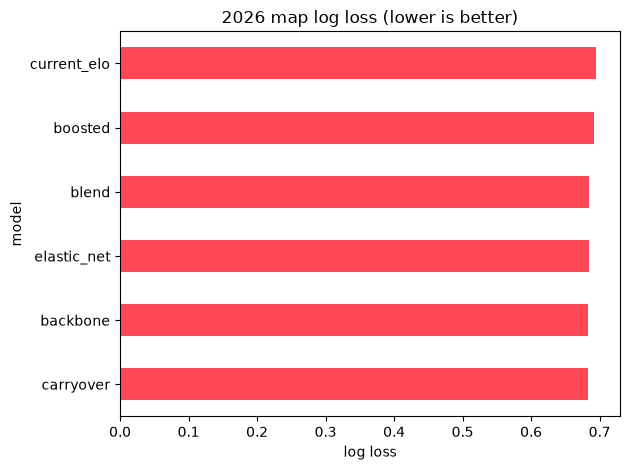

In [3]:
indexed = metrics.set_index("model")
comparison = pd.Series(
    {
        "current Elo log loss": indexed.loc["current_elo", "map_log_loss"],
        "carryover log loss": indexed.loc["carryover", "map_log_loss"],
        "log-loss improvement": indexed.loc["current_elo", "map_log_loss"] - indexed.loc["carryover", "map_log_loss"],
        "current Elo Brier": indexed.loc["current_elo", "brier"],
        "carryover Brier": indexed.loc["carryover", "brier"],
        "carryover calibration slope": indexed.loc["carryover", "calibration_slope"],
        "holdout maps": indexed.loc["carryover", "maps"],
    },
    name="2026 confirmation",
)
display(comparison.to_frame())

ax = metrics.sort_values("map_log_loss").set_index("model")["map_log_loss"].plot.barh(
    title="2026 map log loss (lower is better)", color="#ff4655"
)
ax.set(xlabel="log loss", ylabel="model")
plt.tight_layout()
plt.show()

The holdout is confirmation, not another tuning set. A model that failed
its development gate remains rejected even if its 2026 point estimate is
favorable. The lockbox marker prevents a second confirmation run for this
frozen experiment.